In [44]:
import pickle

import pandas as pd
import geopandas as gpd

from pathlib import Path

In [45]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [46]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [47]:
eval_results_path = Path("/home/wuhlmann/BA/data/processed_data/evaluation/q_pred_landcover_0903_135428_domain_metrics.p")

with open(eval_results_path, "rb") as f: 
    domain_metrics = pickle.load(f)

In [48]:
#load in training ids, to distinguish between learned and unseen (val, test) cell states 
with open("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/train_basin_ids.txt") as f: 
	train_ids_list = list(map(lambda x: int(x[:-1]),f.readlines())) 
	
for id in lamah_gdf.index: 
	
	if id in train_ids_list: 
		lamah_gdf.loc[id,"train_basin"] = True
	else: 
		lamah_gdf.loc[id, "train_basin"] = False

In [49]:
for period in domain_metrics.keys():
	
	for basin_id in domain_metrics[period].keys():
		lamah_gdf.loc[int(basin_id), "period"] = period
		lamah_gdf.loc[int(basin_id), "NSE"] = domain_metrics[period][basin_id]["1D"]["NSE"]

In [67]:
lamah_gdf[lamah_gdf.period == "test"].NSE.max()

0.9063213989138603

In [51]:
lamah_gdf[lamah_gdf.NSE < 0].NSE

ID
11    -1.615288
18    -0.108202
65    -5.904163
120   -0.470889
121   -0.933850
144   -0.286406
160   -0.836513
390   -0.191085
394   -0.431552
399   -2.013988
406   -0.631614
435   -4.010378
521   -0.592196
543   -3.833629
584   -0.486582
589   -0.096801
595   -0.876100
596   -0.129608
629   -3.355013
685   -0.109243
763   -0.412200
Name: NSE, dtype: float64

<Axes: >

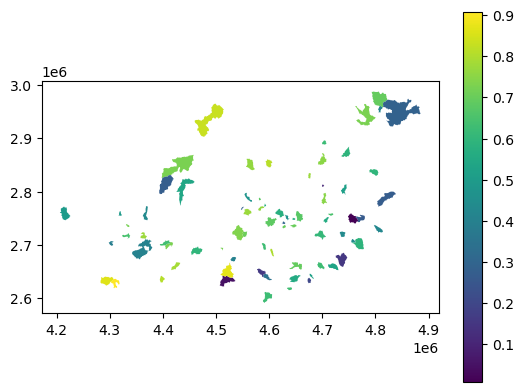

In [68]:
lamah_gdf[(lamah_gdf.NSE > 0) & (lamah_gdf.period == "test")].plot(column="NSE", legend=True)